In [ ]:
# Шаг 1. Разметка целевых действий и формирование датасета
import pandas as pd
import numpy as np
import gc
import os

print("ШАГ 1. ЗАГРУЗКА ДАННЫХ И РАЗМЕТКА ТАРЕГЕТА")

# 1. Список целевых действий из глоссария
target_actions = {
    'sub_car_claim_click',
    'sub_car_claim_submit_click',
    'sub_open_dialog_click',
    'sub_custom_question_submit_click',
    'sub_call_number_click',
    'sub_callback_submit_click',
    'sub_submit_success',
    'sub_car_request_submit_click'
}

print(f"Список target_actions определён, элементов: {len(target_actions)}")

# 2. Проверка наличия файлов
hits_file = 'hits.csv'
sessions_file = 'sessions.pkl'

if not os.path.exists(hits_file):
    raise FileNotFoundError(f"Файл '{hits_file}' не найден в рабочей директории!")
if not os.path.exists(sessions_file):
    raise FileNotFoundError(f"Файл '{sessions_file}' не найден в рабочей директории!")

print(f"Файлы найдены: {hits_file}, {sessions_file}")

# 3. Диагностика структуры hits.csv (читаем первые 1000 строк)
print(f"\n- ДИАГНОСТИКА ФАЙЛА hits.csv -")
sample = pd.read_csv(hits_file, nrows=1000)
print(f"Колонки в файле: {list(sample.columns)}")

if 'event_action' not in sample.columns:
    print("Колонка 'event_action' НЕ НАЙДЕНА!")
    print(f"Доступные колонки: {list(sample.columns)}")
    similar = [c for c in sample.columns if 'event' in c.lower() or 'action' in c.lower()]
    print(f"Похожие колонки: {similar}")
    raise KeyError("Колонка 'event_action' не найдена. Проверьте структуру файла.")

if 'session_id' not in sample.columns:
    print("Колонка 'session_id' НЕ НАЙДЕНА!")
    raise KeyError("Колонка 'session_id' не найдена.")

print(f"Колонки 'session_id' и 'event_action' присутствуют")

# Показываем примеры значений event_action
print(f"\nПримеры значений event_action (топ-15):")
print(sample['event_action'].value_counts().head(15).to_string())

# Проверка пересечения с target_actions
sample_actions = set(sample['event_action'].dropna().unique())
intersection = sample_actions & target_actions
print(f"\nПересечение sample значений с target_actions: {len(intersection)} из {len(target_actions)}")
if len(intersection) == 0:
    print("Ни одно значение из sample не совпадает с target_actions!")
    print("Возможная причина: разный регистр, пробелы или другие названия.")
    print(f"Примеры из файла: {list(sample_actions)[:3]}")
    # НЕ прерываем, т.к. целевые события могут встречаться дальше по файлу

# 4. Чтение hits.csv чанками и сборка целевых сессий
print(f"\n- СКАНИРОВАНИЕ hits.csv НА ЦЕЛЕВЫЕ СОБЫТИЯ -")
target_sessions = set()
total_target_hits = 0
total_rows = 0
chunk_count = 0

for chunk in pd.read_csv(hits_file, usecols=["session_id", "event_action"], chunksize=500_000):
    chunk_count += 1
    total_rows += len(chunk)

    target_hits = chunk[chunk["event_action"].isin(target_actions)]
    total_target_hits += len(target_hits)

    # Пополнение множества уникальных session_id
    target_sessions.update(target_hits["session_id"].dropna().unique())

    # Прогресс каждые 10 чанков
    if chunk_count % 10 == 0:
        print(f"  Обработано чанков: {chunk_count}, строк: {total_rows:,}, целевых хитов: {total_target_hits:,}")

print(f"\nИтого по hits.csv:")
print(f"  • Прочитано строк: {total_rows:,}")
print(f"  • Прочитано чанков: {chunk_count}")
print(f"  • Целевых хитов найдено: {total_target_hits:,}")
print(f"  • Уникальных целевых сессий: {len(target_sessions):,}")

if len(target_sessions) == 0:
    # Если всё-таки ничего не найдено, вывод всех уникальных значений для диагностики
    print("\nЦелевые сессии не найдены. Вывожу все уникальные event_action:")
    all_actions = set()
    for chunk in pd.read_csv(hits_file, usecols=["event_action"], chunksize=500_000):
        all_actions.update(chunk['event_action'].dropna().unique())
    for action in sorted(all_actions):
        print(f"  '{action}'")
    raise ValueError("Целевые сессии не найдены. Прерывание выполнения.")

# 5. Загрузка sessions.pkl
print(f"\n- ЗАГРУЗКА {sessions_file} -")
df = pd.read_pickle(sessions_file)
print(f"Исходный размер df_sessions: {df.shape}")
print(f"Колонки: {list(df.columns)}")
df.head(10)

# 6. Разметка таргета
df['target'] = df['session_id'].isin(target_sessions).astype('int8')

# Освобождение памяти
del target_sessions
gc.collect()

print(f"\n- РАСПРЕДЕЛЕНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ -")
print(df['target'].value_counts(dropna=False))
print(f"\nОбщий CR по всей базе: {df['target'].mean() * 100:.2f}%")
print(f"Целевых сессий: {df['target'].sum():,} из {len(df):,}")

if df['target'].sum() > 0:
    print("\nШАГ 1 ЗАВЕРШЁН")
else:
    print("\nШАГ 1 ЗАВЕРШЁН С ОШИБКОЙ")
print(f"Общий CR по всей базе: {df['target'].mean() * 100:.2f}%")

ШАГ 1. ЗАГРУЗКА ДАННЫХ И РАЗМЕТКА ТАРЕГЕТА
Список target_actions определён, элементов: 8
Файлы найдены: hits.csv, sessions.pkl

- ДИАГНОСТИКА ФАЙЛА hits.csv -
Колонки в файле: ['session_id', 'hit_date', 'hit_time', 'hit_number', 'hit_type', 'hit_referer', 'hit_page_path', 'event_category', 'event_action', 'event_label', 'event_value']
Колонки 'session_id' и 'event_action' присутствуют

Примеры значений event_action (топ-15):
event_action
view_card      983
quiz_show        9
sub_landing      8

Пересечение sample значений с target_actions: 0 из 8
Ни одно значение из sample не совпадает с target_actions!
Возможная причина: разный регистр, пробелы или другие названия.
Примеры из файла: ['quiz_show', 'sub_landing', 'view_card']

- СКАНИРОВАНИЕ hits.csv НА ЦЕЛЕВЫЕ СОБЫТИЯ -
  Обработано чанков: 10, строк: 5,000,000, целевых хитов: 31,093
  Обработано чанков: 20, строк: 10,000,000, целевых хитов: 68,895
  Обработано чанков: 30, строк: 15,000,000, целевых хитов: 100,857

Итого по hits.csv:
 

In [ ]:
# Шаг 2. Очистка данных и создание флагов для гипотез
import pandas as pd
import numpy as np

print("ШАГ 2. ОЧИСТКА ДАННЫХ И СОЗДАНИЕ ПРИЗНАКОВ")

# 1. Проверка и удаление дубликатов
initial_count = len(df)
df = df.drop_duplicates(subset=['session_id']).reset_index(drop=True)
print(f"Удалено дубликатов по session_id: {initial_count - len(df)}")

# 2. Анализ и удаление "пустых" атрибутов
print(f"\n- АНАЛИЗ ПРОПУСКОВ -")
missing_ratio = df.isna().mean().sort_values(ascending=False)
print("Доля пропусков по столбцам:")
print(missing_ratio[missing_ratio > 0].to_string())

cols_to_drop = missing_ratio[missing_ratio > 0.7].index.tolist()
if cols_to_drop:
    print(f"\nВыброшены атрибуты с долей пропусков > 70%: {cols_to_drop}")
    df = df.drop(columns=cols_to_drop)
else:
    print("\nАтрибутов с критичной долей пропусков (>70%) не найдено.")

# 3. Приведение типов данных
df['visit_date'] = pd.to_datetime(df['visit_date'], errors='coerce')

# Заполнение текстовых пропусков
str_cols = [
    'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
    'utm_keyword', 'device_category', 'device_os', 'device_brand',
    'device_model', 'device_screen_resolution', 'device_browser',
    'geo_country', 'geo_city'
]

for col in str_cols:
    if col in df.columns:
        df[col] = df[col].fillna('(not set)').astype(str)

# 4. Разметка категорий для гипотез

# Гипотеза 1: Органический vs Платный трафик
organic_mediums = {'organic', 'referral', '(none)'}
df['is_organic'] = df['utm_medium'].str.lower().isin(organic_mediums).astype('int8')

# Гипотеза 2: Мобильные vs Десктоп
df['is_mobile'] = (df['device_category'].str.lower() == 'mobile').astype('int8')

# Вопрос бизнеса: Трафик из соцсетей
social_sources = {
    'QxAxdyPLuQMEcrdZWdWb',
    'MvfHsxITijuriZxsqZqt',
    'ISrKoXQCxqqYvAZICvjs',
    'IZEXUFLARCUMynmHNBGo',
    'PlbkrSYoHuZBWfYjYnfw',
    'gVRrcxiDQubJiljoTbGm'
}
df['utm_source'] = df['utm_source'].astype(str)
df['is_social'] = df['utm_source'].isin(social_sources).astype('int8')

# Гипотеза 3: Города присутствия
# Москва и область, Санкт-Петербург vs Другие регионы
geo = df['geo_city'].fillna('(not set)').astype(str).str.strip().str.lower()
df['geo_city_clean'] = geo

# Отдельно фиксируется неизвестная география
df['is_geo_missing'] = geo.isin(['(not set)', 'not set', 'nan', 'none', '']).astype('int8')

# Москва и территории, которые могут относиться к Москве
moscow_pattern = (
    r'moscow|moskva|moskovsk|москв|'
    r'zelenograd|зеленоград|'
    r'troitsk|троицк|'
    r'shcherbinka|щербинка|'
    r'moskovskiy|московский|'
    r'krasnaya pakhra|красная пахра'
)

# Санкт-Петербург
spb_pattern = (
    r'saint.?peter|sankt.?peter|st.?peter|spb|'
    r'санкт.?петербург|спб'
)

# Московская область: максимально широкий список городов и округов
moscow_oblast_pattern = (
    r'khimki|himki|химки|'
    r'balashikha|балашиха|'
    r'krasnogorsk|красногорск|'
    r'mytishchi|мытищи|'
    r'podolsk|подольск|'
    r'odintsovo|одинцово|'
    r'lyubertsy|люберцы|'
    r'reutov|реутов|'
    r'shchyolkovo|shchelkovo|щелково|щёлково|'
    r'zhukovsky|жуковский|'
    r'pushkino|пушкино|'
    r'ramenskoye|раменское|'
    r'serpukhov|серпухов|'
    r'elektrostal|электросталь|'
    r'noginsk|ногинск|'
    r'domodedovo|домодедово|'
    r'vidnoye|видное|'
    r'dolgoprudny|долгпрудный|'
    r'kotelniki|котельники|'
    r'korolev|korolyov|королёв|королев|'
    r'lobnya|лобня|'
    r'istra|истра|'
    r'klin|клин|'
    r'solnechnogorsk|солнечногорск|'
    r'dmitrov|дмитров|'
    r'naro.?fominsk|наро.?фоминск|'
    r'voskresensk|воскресенск|'
    r'stupino|ступино|'
    r'chekhov|чехов|'
    r'kolomna|коломна|'
    r'orekhovo.?zuevo|орехово.?зуево|'
    r'pavlovsk(?:y|iy).?posad|павловский.?посад|'
    r'egoryevsk|егорьевск|'
    r'sergiev.?posad|сергиев.?посад|'
    r'krasnoznamensk|краснознаменск|'
    r'vlasikha|власиха|'
    r'zvyozdny.?gorodok|звёздный.?городок|звездный.?городок|'
    r'molodyozhny|молодёжный|молодежный|'
    r'krasnoarmeysk|красноармейск|'
    r'losino.?petrovsky|лосино.?петровский|'
    r'chernogolovka|черноголовка|'
    r'dzerzhinsky|дзержинский|'
    r'bronnytsy|бронницы|'
    r'protvino|протвино|'
    r'puschino|пущино|'
    r'fryazino|frjazino|фрязино|'
    r'yubileyny|юбилейный|'
    r'zheleznodorozhny|железнодорожный|'
    r'zvenigorod|звенигород|'
    r'volokolamsk|волоколамск|'
    r'kashira|кашира|'
    r'lukhovitsy|луховицы|'
    r'mozhaysk|можайск|'
    r'ozery|озёры|озеры|'
    r'roshal|рошаль|'
    r'ruza|руза|'
    r'shatura|шатура|'
    r'khotkovo|хотьково|'
    r'elektrogorsk|электрогорск|'
    r'elektrougli|электроугли|'
    r'staraya kupavna|старая купавна|'
    r'taldom|талдом|'
    r'dubna|дубна|'
    r'zaraysk|зарайск|'
    r'ivanteevka|ивантеевка|'
    r'kubinka|кубинка|'
    r'likino.?dulevo|ликино.?дулёво|ликино.?дулево'
)

df['is_moscow_city'] = geo.str.contains(
    moscow_pattern,
    regex=True,
    na=False
).astype('int8')

df['is_spb'] = geo.str.contains(
    spb_pattern,
    regex=True,
    na=False
).astype('int8')

df['is_moscow_oblast'] = geo.str.contains(
    moscow_oblast_pattern,
    regex=True,
    na=False
).astype('int8')

df['is_target_geo'] = (
    (df['is_moscow_city'] == 1) |
    (df['is_spb'] == 1) |
    (df['is_moscow_oblast'] == 1)
).astype('int8')

print("\n- ПРОВЕРКА ИСПРАВЛЕННОЙ ГЕОГРАФИИ -")
print(f"Доля городов присутствия: {df['is_target_geo'].mean() * 100:.2f}%")
print(f"Доля пропусков географии: {df['is_geo_missing'].mean() * 100:.2f}%")
print("\nТоп-20 городов/значений, которые теперь отнесены к городам присутствия:")
print(df.loc[df['is_target_geo'] == 1, 'geo_city_clean'].value_counts().head(20).to_string())


# Проверка, что все нужные признаки созданы
required_flags = [
    'target',
    'is_organic',
    'is_mobile',
    'is_target_geo',
    'is_social',
    'is_geo_missing'
]

missing_flags = [col for col in required_flags if col not in df.columns]

if missing_flags:
    raise KeyError(
        f"В датасете отсутствуют обязательные признаки: {missing_flags}. "
        f"Проверьте код создания признаков в Шаге 2."
    )

print("\nВсе необходимые признаки созданы:", required_flags)

# 5. Итоговая сводка
print(f"\n- ИТОГОВАЯ СВОДКА ПО СОЗДАННЫМ ПРИЗНАКАМ -")
print(f"Всего сессий в датасете: {len(df):,}")
print(f"Целевых сессий (target=1): {df['target'].sum():,}")
print(f"Общий CR: {df['target'].mean() * 100:.2f}%")
print()
print(f"Доля органического трафика: {df['is_organic'].mean() * 100:.2f}%")
print(f"Доля мобильного трафика: {df['is_mobile'].mean() * 100:.2f}%")
print(f"Доля целевых регионов: {df['is_target_geo'].mean() * 100:.2f}%")
print(f"Доля соцсетей: {df['is_social'].mean() * 100:.2f}%")

# 6. Дополнительная проверка: примеры городов для контроля regex
print(f"\n- ПРОВЕРКА ГЕОГРАФИИ (топ-10 городов) -")
print(df['geo_city'].value_counts().head(10).to_string())

print("\nШАГ 2 ЗАВЕРШЁН")

ШАГ 2. ОЧИСТКА ДАННЫХ И СОЗДАНИЕ ПРИЗНАКОВ
Удалено дубликатов по session_id: 0

- АНАЛИЗ ПРОПУСКОВ -
Доля пропусков по столбцам:
device_model     0.991216
utm_keyword      0.581740
device_os        0.575330
utm_adcontent    0.180434
utm_campaign     0.118063
device_brand     0.063804
utm_source       0.000052

Выброшены атрибуты с долей пропусков > 70%: ['device_model']

- ПРОВЕРКА ИСПРАВЛЕННОЙ ГЕОГРАФИИ -
Доля городов присутствия: 64.60%
Доля пропусков географии: 4.20%

Топ-20 городов/значений, которые теперь отнесены к городам присутствия:
geo_city_clean
moscow              805329
saint petersburg    296788
balashikha           12679
khimki                7385
vidnoye               5358
odintsovo             5314
mytishchi             5284
zheleznodorozhny      4916
korolyov              4047
domodedovo            4038
podolsk               3621
krasnogorsk           3292
dolgoprudny           2713
lyubertsy             2497
pushkino              2446
reutov                2375
shchy

In [ ]:
# Шаг 3a. Корректное соединение таблиц sessions и hits

import pandas as pd
import numpy as np

print("ШАГ 3a. СОЕДИНЕНИЕ ТАБЛИЦ sessions И hits")

session_stats_list = []
unique_pairs_list = []  # для точного подсчёта unique_pages
print("Чтение hits.csv и агрегация по сессиям")

# Диагностика и удаление дубликатов хитов внутри чанков
hit_dedup_cols = ['session_id', 'hit_number', 'event_action', 'hit_page_path']
total_hit_rows = 0
hit_duplicates_removed = 0

for i, chunk in enumerate(pd.read_csv(
    "hits.csv",
    usecols=["session_id", "hit_number", "event_action", "hit_page_path"],
    chunksize=500_000)):

    # 1. Счет исходного количества строк
    rows_before = len(chunk)

    # 2. Удаление дубликатов и ОБЯЗАТЕЛЬНО сделать .copy()
    # Это разрывает связь с исходным буфером чтения и предотвращает SettingWithCopyWarning
    chunk = chunk.drop_duplicates(subset=hit_dedup_cols, keep='first').copy()

    total_hit_rows += rows_before
    hit_duplicates_removed += rows_before - len(chunk)

    # 3. Помечаем целевые события в чанке
    chunk = chunk.assign(is_target_event=chunk['event_action'].isin(target_actions).astype('int8'))

    # Агрегация total_events и target_events по сессиям внутри чанка
    chunk_agg = chunk.groupby('session_id').agg(
        total_events=('hit_number', 'count'),
        target_events=('is_target_event', 'sum')
    ).reset_index()
    session_stats_list.append(chunk_agg)

    # Для unique_pages копим уникальные пары (session_id, страница) по каждому чанку
    pairs = chunk[['session_id', 'hit_page_path']].drop_duplicates()
    unique_pairs_list.append(pairs)

    if (i + 1) % 10 == 0:
        print(f"  Обработано чанков: {i + 1}")

print(f"\nОбработано строк hits: {total_hit_rows:,}")
print(f"Удалено дубликатов хитов внутри чанков: {hit_duplicates_removed:,}")

if hit_duplicates_removed == 0:
    print("Дубликаты в hits не обнаружены.")
else:
    print("Метрики total_events/target_events будут считаться уже без удалённых дубликатов.")

# Объединение total_events / target_events (простое суммирование корректно)
df_session_stats = pd.concat(session_stats_list, ignore_index=True)
del session_stats_list

df_session_stats = df_session_stats.groupby('session_id').agg(
    total_events=('total_events', 'sum'),
    target_events=('target_events', 'sum')
).reset_index()

# Точный подсчёт unique_pages: сначала убираем дубликаты пар между чанками,
# затем считаем nunique один раз
all_pairs = pd.concat(unique_pairs_list, ignore_index=True).drop_duplicates()
del unique_pairs_list

unique_pages_df = all_pairs.groupby('session_id').size().reset_index(name='unique_pages')
del all_pairs

df_session_stats = df_session_stats.merge(unique_pages_df, on='session_id', how='left')
del unique_pages_df

print(f"Агрегировано сессий из hits: {len(df_session_stats):,}")

# LEFT JOIN: все сессии из df сохраняются
df_merged = df.merge(df_session_stats, on='session_id', how='left')

# Заполнение пропусков (сессии, для которых не нашлось хитов)
# Использование np.int32 для экономии памяти и избежания потенциальных FutureWarning
for col in ['total_events', 'unique_pages', 'target_events']:
    df_merged[col] = df_merged[col].fillna(0).astype(np.int32)

print(f"Размер объединённого датасета: {df_merged.shape}")
print(f"\nСтатистика total_events (событий на сессию):")
print(df_merged['total_events'].describe().round(2))
print(f"\nСтатистика unique_pages (уникальных страниц на сессию):")
print(df_merged['unique_pages'].describe().round(2))
print(f"\nТаблицы sessions и hits корректно соединены (LEFT JOIN по session_id)")

ШАГ 3a. СОЕДИНЕНИЕ ТАБЛИЦ sessions И hits
Чтение hits.csv и агрегация по сессиям
  Обработано чанков: 10
  Обработано чанков: 20
  Обработано чанков: 30

Обработано строк hits: 15,726,470
Удалено дубликатов хитов внутри чанков: 26,982
Метрики total_events/target_events будут считаться уже без удалённых дубликатов.
Агрегировано сессий из hits: 1,734,610
Размер объединённого датасета: (1860042, 30)

Статистика total_events (событий на сессию):
count    1860042.00
mean           8.42
std           13.55
min            0.00
25%            1.00
50%            3.00
75%           10.00
max          707.00
Name: total_events, dtype: float64

Статистика unique_pages (уникальных страниц на сессию):
count    1860042.00
mean           1.73
std            1.43
min            0.00
25%            1.00
50%            1.00
75%            2.00
max           45.00
Name: unique_pages, dtype: float64

Таблицы sessions и hits корректно соединены (LEFT JOIN по session_id)


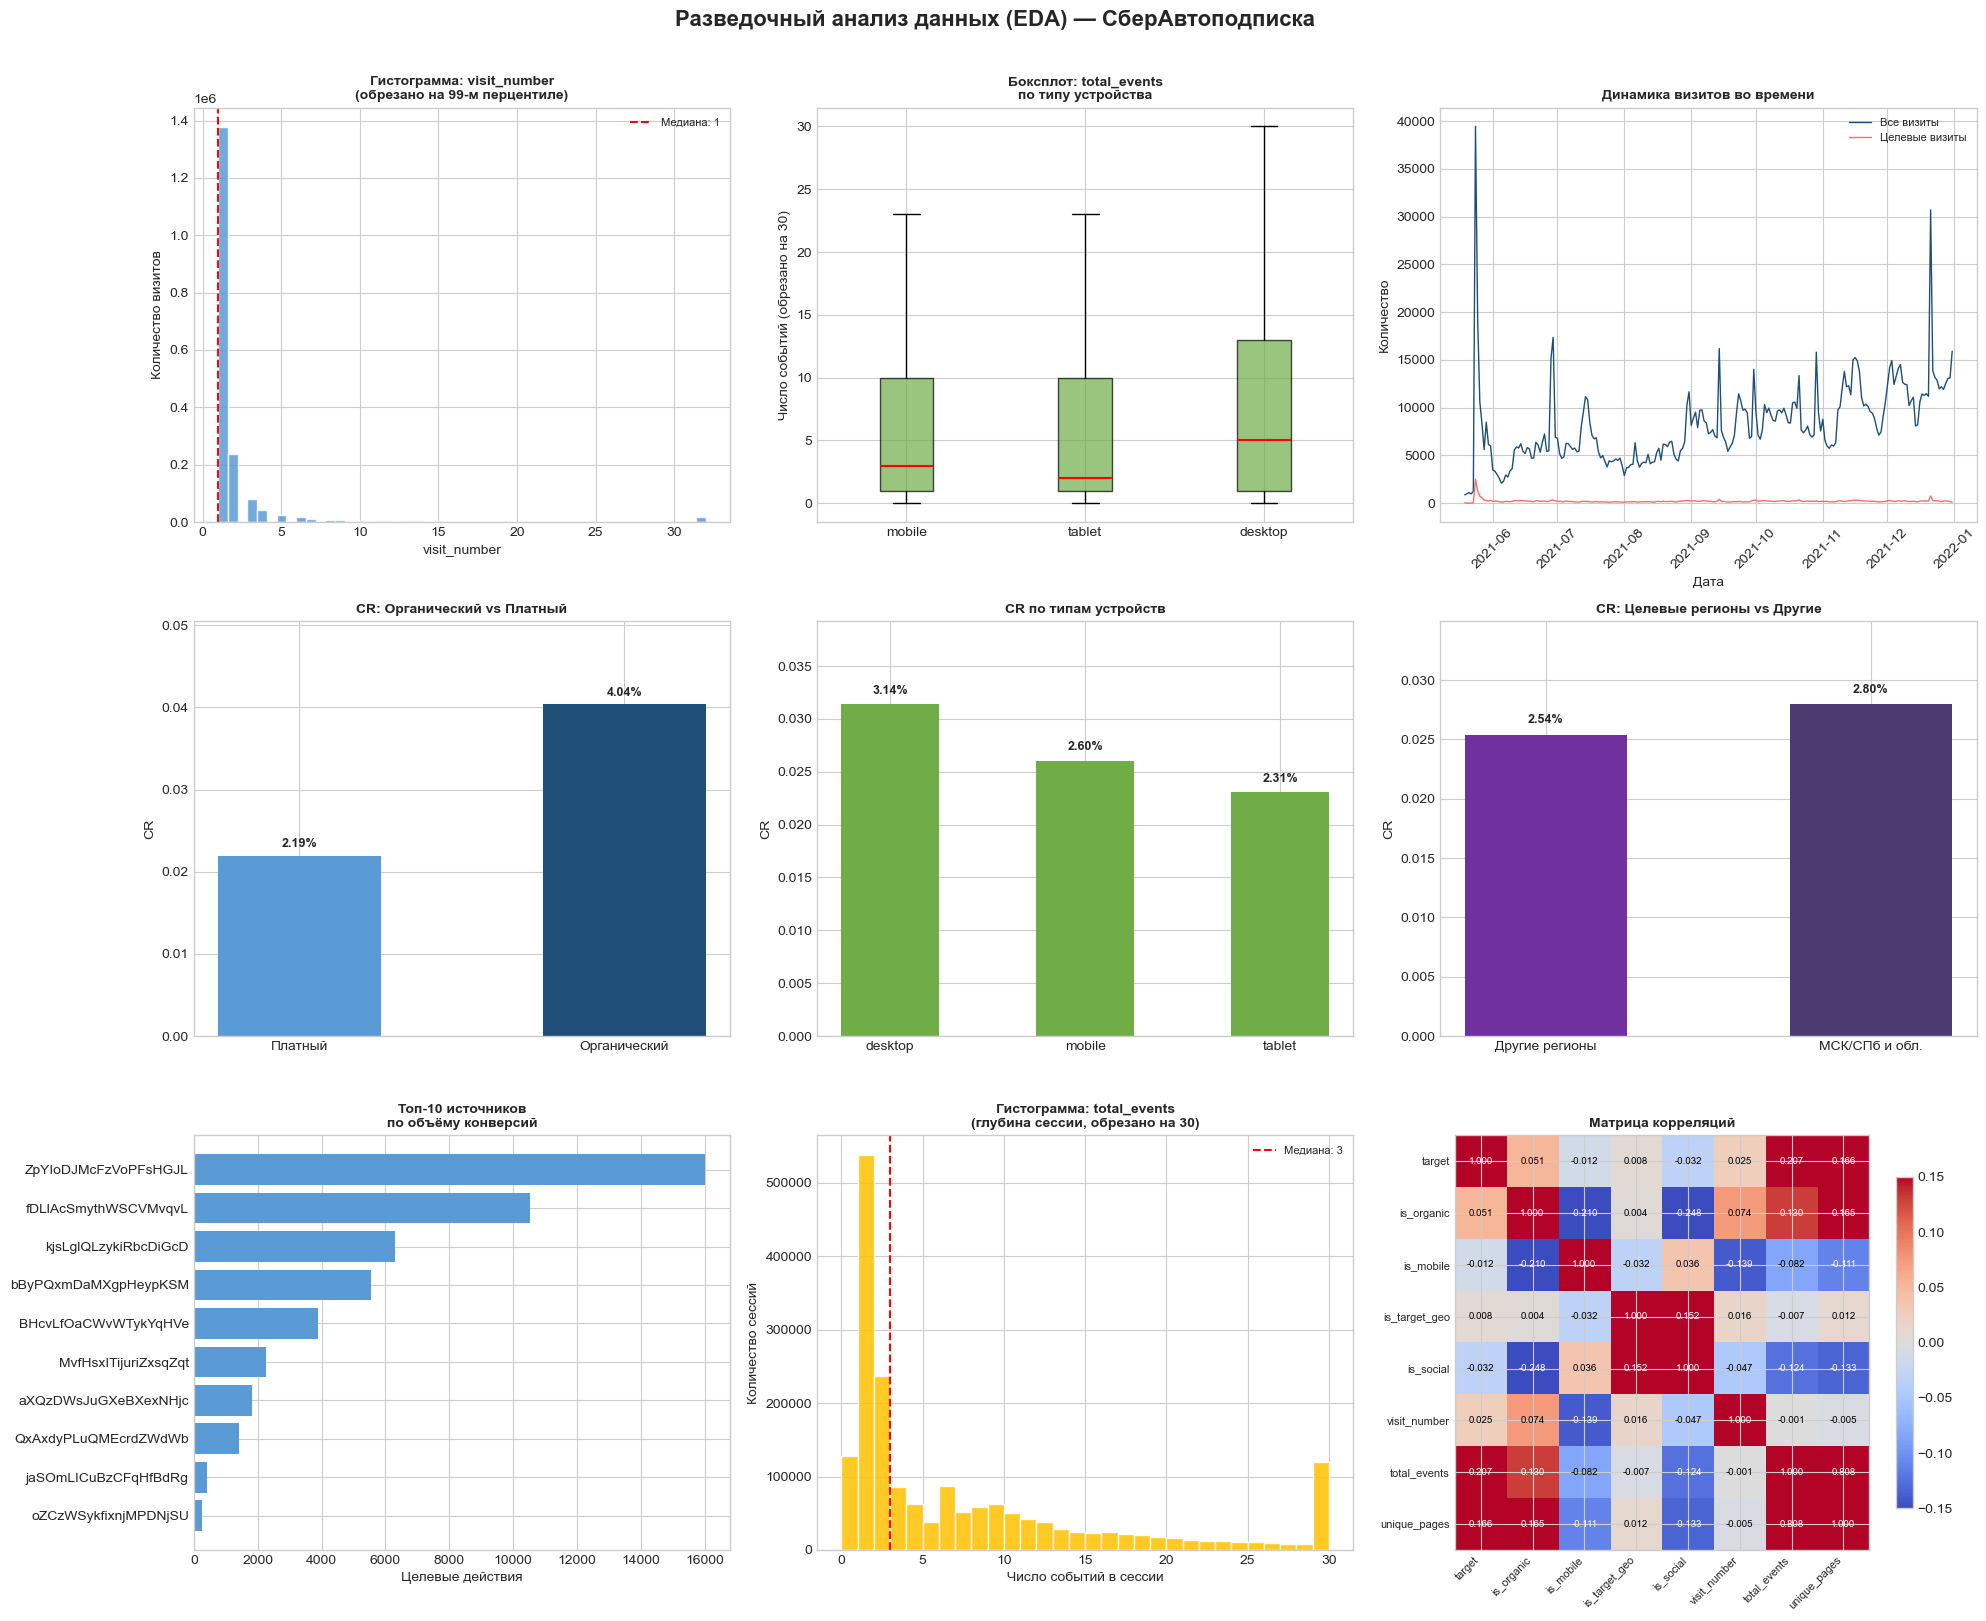

ВЫВОДЫ ПО МАТРИЦЕ КОРРЕЛЯЦИЙ

Корреляции признаков с целевой переменной (target):
  • total_events   : +0.2067 (умеренная, положительная)
  • unique_pages   : +0.1657 (умеренная, положительная)
  • is_organic     : +0.0508 (слабая, положительная)
  • is_social      : -0.0318 (слабая, отрицательная)
  • visit_number   : +0.0253 (слабая, положительная)
  • is_mobile      : -0.0124 (слабая, отрицательная)
  • is_target_geo  : +0.0075 (слабая, положительная)

Интерпретация:
  • Сильнее всего с target связан total_events (+0.2067):
    чем глубже сессия, тем выше вероятность целевого действия.
  • is_organic (+0.0508): органический трафик конвертируется лучше платного.
  • is_social (-0.0318): трафик из соцсетей конвертируется хуже среднего.
  • is_mobile и is_target_geo близки к нулю — устройство и география
    слабо влияют на конверсию (проверим статистически в Шаге 4).


In [ ]:
# Шаг 3b. Разведочный анализ данных (EDA)
import matplotlib.pyplot as plt
import numpy as np

# ПРОВЕРКА: все ли необходимые колонки на месте
required_cols = ['target', 'is_organic', 'is_mobile', 'is_target_geo',
                 'is_social', 'visit_number', 'visit_date',
                 'device_category', 'utm_source']
missing_cols = [c for c in required_cols if c not in df_merged.columns]
if missing_cols:
    raise KeyError(
        f"В датасете отсутствуют колонки: {missing_cols}.\n"
        f"Перезапустите ядро (Kernel → Restart) и запустите "
        f"все ячейки по порядку: Шаг 1 → Шаг 2 → Шаг 3a → Шаг 3b."
    )

# Использование df_merged (все колонки df + total_events, unique_pages, target_events)
data = df_merged

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('Разведочный анализ данных (EDA) — сервис подписки на авто',
             fontsize=16, fontweight='bold', y=1.01)


# РЯД 1: Распределения

# 1. Гистограмма: распределение visit_number
vn_clipped = data['visit_number'].clip(upper=data['visit_number'].quantile(0.99))
axes[0, 0].hist(vn_clipped, bins=50, color='#5b9bd5', edgecolor='white', alpha=0.85)
axes[0, 0].set_title('Гистограмма: visit_number\n(обрезано на 99-м перцентиле)', fontsize=10, fontweight='bold')
axes[0, 0].set_xlabel('visit_number')
axes[0, 0].set_ylabel('Количество визитов')
axes[0, 0].axvline(data['visit_number'].median(), color='red', linestyle='--', linewidth=1.5,
                   label=f"Медиана: {data['visit_number'].median():.0f}")
axes[0, 0].legend(fontsize=8)

# 2. Боксплот: total_events по типам устройств (из merged-данных)
device_cats = [c for c in data['device_category'].unique() if c != '(not set)']
box_data = [data[data['device_category'] == c]['total_events'].clip(upper=30).dropna().values
            for c in device_cats]
axes[0, 1].boxplot(box_data, tick_labels=device_cats, patch_artist=True, showfliers=False,
                   boxprops=dict(facecolor='#70ad47', alpha=0.7),
                   medianprops=dict(color='red', linewidth=1.5))
axes[0, 1].set_title('Боксплот: total_events\nпо типу устройства', fontsize=10, fontweight='bold')
axes[0, 1].set_ylabel('Число событий (обрезано на 30)')

# 3. Динамика визитов и целевых событий во времени
daily = data.groupby('visit_date').agg(visits=('session_id', 'count'), targets=('target', 'sum'))
axes[0, 2].plot(daily.index, daily['visits'], color='#1f4e78', linewidth=1, label='Все визиты')
axes[0, 2].plot(daily.index, daily['targets'], color='#ff6b6b', linewidth=1, label='Целевые визиты')
axes[0, 2].set_title('Динамика визитов во времени', fontsize=10, fontweight='bold')
axes[0, 2].set_xlabel('Дата')
axes[0, 2].set_ylabel('Количество')
axes[0, 2].legend(fontsize=8)
axes[0, 2].tick_params(axis='x', rotation=45)


# РЯД 2: CR по ключевым срезам

# 4. CR: Органический vs Платный
cr_org = data.groupby('is_organic')['target'].mean()
bars = axes[1, 0].bar(['Платный', 'Органический'],
                      [cr_org.get(0, 0), cr_org.get(1, 0)],
                      color=['#5b9bd5', '#1f4e78'], width=0.5)
for b in bars:
    axes[1, 0].text(b.get_x() + b.get_width()/2., b.get_height() + 0.001,
                    f'{b.get_height()*100:.2f}%', ha='center', fontweight='bold', fontsize=9)
axes[1, 0].set_title('CR: Органический vs Платный', fontsize=10, fontweight='bold')
axes[1, 0].set_ylabel('CR')
axes[1, 0].set_ylim(0, max(cr_org.values) * 1.25)

# 5. CR по типам устройств
cr_dev = data.groupby('device_category')['target'].mean().sort_values(ascending=False)
bars = axes[1, 1].bar(cr_dev.index, cr_dev.values, color='#70ad47', width=0.5)
for b in bars:
    axes[1, 1].text(b.get_x() + b.get_width()/2., b.get_height() + 0.001,
                    f'{b.get_height()*100:.2f}%', ha='center', fontweight='bold', fontsize=9)
axes[1, 1].set_title('CR по типам устройств', fontsize=10, fontweight='bold')
axes[1, 1].set_ylabel('CR')
axes[1, 1].set_ylim(0, max(cr_dev.values) * 1.25)

# 6. CR: Целевые регионы vs Другие
cr_geo = data.groupby('is_target_geo')['target'].mean()
bars = axes[1, 2].bar(['Другие регионы', 'МСК/СПб и обл.'],
                      [cr_geo.get(0, 0), cr_geo.get(1, 0)],
                      color=['#7030a0', '#4b3b70'], width=0.5)
for b in bars:
    axes[1, 2].text(b.get_x() + b.get_width()/2., b.get_height() + 0.001,
                    f'{b.get_height()*100:.2f}%', ha='center', fontweight='bold', fontsize=9)
axes[1, 2].set_title('CR: Целевые регионы vs Другие', fontsize=10, fontweight='bold')
axes[1, 2].set_ylabel('CR')
axes[1, 2].set_ylim(0, max(cr_geo.values) * 1.25)


# РЯД 3: Источники, глубина сессии, корреляции

# 7. Топ-10 источников по объёму конверсий
top_src = (data.groupby('utm_source')['target']
           .agg(['sum', 'count'])
           .query('count > 1000')
           .nlargest(10, 'sum'))
axes[2, 0].barh(top_src.index[::-1], top_src['sum'][::-1], color='#5b9bd5')
axes[2, 0].set_title('Топ-10 источников\nпо объёму конверсий', fontsize=10, fontweight='bold')
axes[2, 0].set_xlabel('Целевые действия')

# 8. Гистограмма: распределение total_events (глубина сессии)
te_clipped = data['total_events'].clip(upper=30)
axes[2, 1].hist(te_clipped, bins=30, color='#ffc000', edgecolor='white', alpha=0.85)
axes[2, 1].set_title('Гистограмма: total_events\n(глубина сессии, обрезано на 30)', fontsize=10, fontweight='bold')
axes[2, 1].set_xlabel('Число событий в сессии')
axes[2, 1].set_ylabel('Количество сессий')
axes[2, 1].axvline(data['total_events'].median(), color='red', linestyle='--', linewidth=1.5,
                   label=f"Медиана: {data['total_events'].median():.0f}")
axes[2, 1].legend(fontsize=8)

# 9. Расширенная матрица корреляций (heatmap)
corr_cols = ['target', 'is_organic', 'is_mobile', 'is_target_geo',
             'is_social', 'visit_number', 'total_events', 'unique_pages']
corr_matrix = data[corr_cols].corr()

im = axes[2, 2].imshow(corr_matrix.values, cmap='coolwarm', vmin=-0.15, vmax=0.15)
axes[2, 2].set_xticks(range(len(corr_cols)))
axes[2, 2].set_yticks(range(len(corr_cols)))
axes[2, 2].set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=8)
axes[2, 2].set_yticklabels(corr_cols, fontsize=8)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        axes[2, 2].text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=7,
                        color='white' if abs(val) > 0.1 else 'black')

axes[2, 2].set_title('Матрица корреляций', fontsize=10, fontweight='bold')
fig.colorbar(im, ax=axes[2, 2], shrink=0.8)

plt.tight_layout()
plt.show()


# Текстовые выводы по корреляциям
print("ВЫВОДЫ ПО МАТРИЦЕ КОРРЕЛЯЦИЙ")
target_corrs = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
print("\nКорреляции признаков с целевой переменной (target):")
for feat, val in target_corrs.items():
    strength = "слабая" if abs(val) < 0.1 else ("умеренная" if abs(val) < 0.3 else "сильная")
    direction = "положительная" if val > 0 else "отрицательная"
    print(f"  • {feat:15s}: {val:+.4f} ({strength}, {direction})")

top_feat, top_val = target_corrs.index[0], target_corrs.iloc[0]
org_val = target_corrs.get('is_organic', 0)
soc_val = target_corrs.get('is_social', 0)

print("\nИнтерпретация:")
print(f"  • Сильнее всего с target связан {top_feat} ({top_val:+.4f}):")
if top_feat in ('total_events', 'unique_pages'):
    print("    чем глубже сессия, тем выше вероятность целевого действия.")
else:
    print("    данный признак наиболее информативен для предсказания конверсии.")
print(f"  • is_organic ({org_val:+.4f}): органический трафик конвертируется "
      f"{'лучше' if org_val > 0 else 'хуже'} платного.")
print(f"  • is_social ({soc_val:+.4f}): трафик из соцсетей конвертируется "
      f"{'лучше' if soc_val > 0 else 'хуже'} среднего.")
print("  • is_mobile и is_target_geo близки к нулю — устройство и география")
print("    слабо влияют на конверсию (проверим статистически в Шаге 4).")

=== ТОП-10 ИСТОЧНИКОВ (с расшифровкой типа канала) ===
                                   label  sessions  conversions    cr
utm_source                                                           
ZpYIoDJMcFzVoPFsHGJL   ZpYIoD… (Платный)    578290        15998  2.77
fDLlAcSmythWSCVMvqvL  fDLlAc… (Органика)    300575        10531  3.50
kjsLglQLzykiRbcDiGcD   kjsLgl… (Платный)    266354         6293  2.36
bByPQxmDaMXgpHeypKSM  bByPQx… (Органика)    102287         5557  5.43
BHcvLfOaCWvWTykYqHVe   BHcvLf… (Платный)    116320         3882  3.34
MvfHsxITijuriZxsqZqt   MvfHsx… (Соцсети)    186199         2249  1.21
aXQzDWsJuGXeBXexNHjc  aXQzDW… (Органика)     31152         1827  5.86
QxAxdyPLuQMEcrdZWdWb   QxAxdy… (Соцсети)     51415         1404  2.73
jaSOmLICuBzCFqHfBdRg   jaSOmL… (Платный)     29241          401  1.37
oZCzWSykfixnjMPDNjSU  oZCzWS… (Органика)      3143          260  8.27


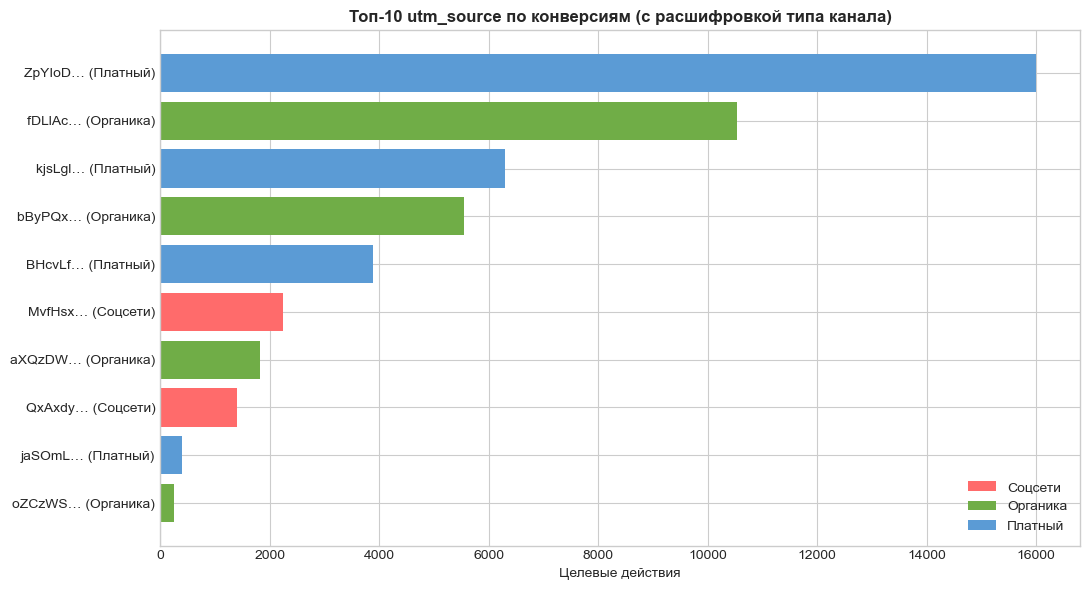

In [ ]:
# Шаг 3c. Интерпретируемость: расшифровка анонимизированных источников
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Определение типа канала для каждого utm_source
src_organic_share = df.groupby('utm_source')['is_organic'].mean()

def get_source_type(src):
    """Относит анонимный источник к читаемому типу канала."""
    if src in social_sources:  # 6 источников, известные из ТЗ
        return 'Соцсети'
    if src_organic_share.get(src, 0) > 0.9:  # >90% визитов органические
        return 'Органика'
    return 'Платный'

# 2. Топ-10 источников с читаемыми подписями
top_src = (df.groupby('utm_source')['target']
           .agg(conversions='sum', sessions='count')
           .query('sessions > 1000')
           .nlargest(10, 'conversions'))

top_src['type'] = [get_source_type(s) for s in top_src.index]
top_src['cr'] = (top_src['conversions'] / top_src['sessions'] * 100).round(2)
top_src['label'] = [f"{s[:6]}… ({t})" for s, t in zip(top_src.index, top_src['type'])]

print("=== ТОП-10 ИСТОЧНИКОВ (с расшифровкой типа канала) ===")
print(top_src[['label', 'sessions', 'conversions', 'cr']].to_string())

# 3. График с цветовой кодировкой типов каналов
color_map = {'Соцсети': '#ff6b6b', 'Органика': '#70ad47', 'Платный': '#5b9bd5'}
plot_df = top_src.iloc[::-1]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(plot_df['label'], plot_df['conversions'],
        color=[color_map[t] for t in plot_df['type']])
ax.set_title('Топ-10 utm_source по конверсиям (с расшифровкой типа канала)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Целевые действия')
ax.legend(handles=[Patch(facecolor=c, label=t) for t, c in color_map.items()],
          loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
# Шаг 4. Проверка статистических гипотез (с размером эффекта и мощностью)
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize
from statsmodels.stats.power import NormalIndPower

ALPHA = 0.05

def run_z_test_enhanced(df, feature_col, val_1, val_0, label_1, label_0, hypothesis_title):
    n_1 = int((df[feature_col] == val_1).sum())
    n_0 = int((df[feature_col] == val_0).sum())
    succ_1 = int(df.loc[df[feature_col] == val_1, 'target'].sum())
    succ_0 = int(df.loc[df[feature_col] == val_0, 'target'].sum())

    cr_1 = succ_1 / n_1
    cr_0 = succ_0 / n_0

    # Z-тест для двух пропорций
    z_stat, p_val = proportions_ztest([succ_1, succ_0], [n_1, n_0], alternative='two-sided')

    # Размер эффекта (Cohen's h) и пост-хок мощность теста
    h = proportion_effectsize(cr_1, cr_0)
    power = NormalIndPower().solve_power(effect_size=abs(h), nobs1=n_1,
                                         ratio=n_0 / n_1, alpha=ALPHA)
    if abs(h) < 0.2: effect_str = 'пренебрежимо малый'
    elif abs(h) < 0.5: effect_str = 'малый'
    elif abs(h) < 0.8: effect_str = 'средний'
    else: effect_str = 'большой'

    lift = (cr_1 - cr_0) / cr_0 * 100 if cr_0 > 0 else float('nan')

    print("=" * 80)
    print(f"ГИПОТЕЗА: {hypothesis_title}")
    print("-" * 80)
    print("СТАТИСТИЧЕСКИЙ КРИТЕРИЙ И ТЕСТ:")
    print(f"  • Критерий: двусторонний Z-тест для двух пропорций")
    print(f"  • Уровень значимости: α = {ALPHA}")
    print("-" * 80)
    print(f"ГРУППЫ:")
    print(f"  • {label_1}: n={n_1:,}, конверсий={succ_1:,}, CR={cr_1*100:.2f}%")
    print(f"  • {label_0}: n={n_0:,}, конверсий={succ_0:,}, CR={cr_0*100:.2f}%")
    print("-" * 80)
    print("РЕЗУЛЬТАТЫ ТЕСТА:")
    print(f"  • Z-статистика: {z_stat:.4f}")
    print(f"  • p-value: {p_val:.4e}")
    print(f"  • Размер эффекта (Cohen's h): {abs(h):.4f} — {effect_str}")
    print(f"  • Мощность теста (1-β): {power:.4f}")
    print(f"  • Относительный lift: {lift:+.1f}%")
    print("-" * 80)
    print("ТЕКСТОВАЯ ИНТЕРПРЕТАЦИЯ:")
    if p_val < ALPHA:
        print(f"  Различие статистически значимо (p < {ALPHA}). Отвергаем H0.")

        abs_diff_pp = abs(cr_1 - cr_0) * 100  # абсолютная разница в п.п.

        if abs(h) < 0.2 and abs(lift) < 20:
            print(f"  Размер эффекта {effect_str} (h={abs(h):.3f}), lift всего {lift:+.1f}%.")
            print(f"  Практической ценности различие не имеет.")
        elif abs(h) < 0.2 and abs(lift) >= 20:
            print(f"  Абсолютная разница CR: {abs_diff_pp:.2f} п.п. (h={abs(h):.3f}, формально '{effect_str}').")
            print(f"  Однако относительный lift {lift:+.1f}% — практически значимое различие для бизнеса.")
        else:
            print(f"  Размер эффекта {effect_str} (h={abs(h):.3f}) — различие практически значимо.")

        if lift > 0:
            print(f"  {label_1} конвертируется на {lift:.1f}% лучше.")
        else:
            print(f"  {label_0} конвертируется на {abs(lift):.1f}% лучше.")
    else:
        print(f"  Различие НЕ статистически значимо (p = {p_val:.4e} >= {ALPHA}).")
        print(f"  Не отвергаем H0 — различие может быть случайным.")
    print("=" * 80)
    print()

# Запуск тестов

# 1. Органический vs Платный
run_z_test_enhanced(df, 'is_organic', 1, 0,
                    'Органический трафик', 'Платный трафик',
                    'Органический трафик не отличается от платного с точки зрения CR')

# 2. Мобильные vs Десктоп
run_z_test_enhanced(df, 'is_mobile', 1, 0,
                    'Мобильные устройства', 'Десктопные устройства',
                    'Трафик с мобильных устройств не отличается от десктопных с точки зрения CR')

# 3. Города присутствия vs Регионы
# Исключение сессий с неизвестной географией, чтобы не смешивать пропуски с "другими регионами"
df_hyp3 = df[df['is_geo_missing'] == 0]
run_z_test_enhanced(df_hyp3, 'is_target_geo', 1, 0,
                    'Города присутствия (МСК/СПб и обл.)', 'Другие регионы',
                    'Трафик из городов присутствия не отличается от трафика из иных регионов с точки зрения CR')

ГИПОТЕЗА: Органический трафик не отличается от платного с точки зрения CR
--------------------------------------------------------------------------------
СТАТИСТИЧЕСКИЙ КРИТЕРИЙ И ТЕСТ:
  • Критерий: двусторонний Z-тест для двух пропорций
  • Уровень значимости: α = 0.05
--------------------------------------------------------------------------------
ГРУППЫ:
  • Органический трафик: n=515,659, конверсий=20,812, CR=4.04%
  • Платный трафик: n=1,344,383, конверсий=29,502, CR=2.19%
--------------------------------------------------------------------------------
РЕЗУЛЬТАТЫ ТЕСТА:
  • Z-статистика: 69.3000
  • p-value: 0.0000e+00
  • Размер эффекта (Cohen's h): 0.1072 — пренебрежимо малый
  • Мощность теста (1-β): 1.0000
  • Относительный lift: +83.9%
--------------------------------------------------------------------------------
ТЕКСТОВАЯ ИНТЕРПРЕТАЦИЯ:
  Различие статистически значимо (p < 0.05). Отвергаем H0.
  Абсолютная разница CR: 1.84 п.п. (h=0.107, формально 'пренебрежимо малый').

In [ ]:
# ШАГ 5. ОТВЕТЫ НА БИЗНЕС-ВОПРОСЫ

import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest, proportion_effectsize

print("ОТВЕТЫ НА БИЗНЕС-ВОПРОСЫ")

# --- Функция определения типа канала (дублирую из Шага 3c для автономности) ---
src_organic_share = df.groupby('utm_source')['is_organic'].mean()

def get_source_type(src):
    if src in social_sources:
        return 'Соцсети'
    if src_organic_share.get(src, 0) > 0.9:
        return 'Органика'
    return 'Платный'

# =========================================================
print("\n" + "=" * 80)
print("1. САМЫЙ ЦЕЛЕВОЙ ТРАФИК ПО ИСТОЧНИКАМ (utm_source)")
print("=" * 80)

source_stats = df.groupby('utm_source').agg(
    sessions=('session_id', 'count'),
    conversions=('target', 'sum'),
    cr=('target', 'mean')
).reset_index()

source_stats['cr_pct'] = (source_stats['cr'] * 100).round(2)
# расшифровка типа канала
source_stats['channel_type'] = source_stats['utm_source'].apply(get_source_type)

top_by_volume = (source_stats[source_stats['sessions'] >= 1000]
                 .nlargest(10, 'conversions'))

print("\nТоп-10 источников по ОБЪЁМУ целевых действий:")
print(top_by_volume[['channel_type', 'utm_source', 'sessions', 'conversions', 'cr_pct']]
      .to_string(index=False))

top_by_cr = (source_stats[source_stats['sessions'] >= 1000]
             .nlargest(10, 'cr_pct'))

print("\nТоп-10 источников по CR (Conversion Rate):")
print(top_by_cr[['channel_type', 'utm_source', 'sessions', 'conversions', 'cr_pct']]
      .to_string(index=False))


print("\n" + "=" * 80)
print("2. САМЫЙ ЦЕЛЕВОЙ ТРАФИК ПО КАМПАНИЯМ (utm_campaign)")
print("=" * 80)

campaign_stats = df.groupby('utm_campaign').agg(
    sessions=('session_id', 'count'),
    conversions=('target', 'sum'),
    cr=('target', 'mean')
).reset_index()

campaign_stats['cr_pct'] = (campaign_stats['cr'] * 100).round(2)

top_camp_volume = (campaign_stats[campaign_stats['sessions'] >= 1000]
                   .nlargest(10, 'conversions'))

print("\nТоп-10 кампаний по ОБЪЁМУ целевых действий:")
print(top_camp_volume[['utm_campaign', 'sessions', 'conversions', 'cr_pct']]
      .to_string(index=False))

top_camp_cr = (campaign_stats[campaign_stats['sessions'] >= 500]
               .nlargest(10, 'cr_pct'))

print("\nТоп-10 кампаний по CR:")
print(top_camp_cr[['utm_campaign', 'sessions', 'conversions', 'cr_pct']]
      .to_string(index=False))


print("\n" + "=" * 80)
print("3. САМЫЙ ЦЕЛЕВОЙ ТРАФИК ПО УСТРОЙСТВАМ (device_category)")
print("=" * 80)

device_stats = df.groupby('device_category').agg(
    sessions=('session_id', 'count'),
    conversions=('target', 'sum'),
    cr=('target', 'mean')
).reset_index()

device_stats['cr_pct'] = (device_stats['cr'] * 100).round(2)

print("\nКонверсия по типам устройств:")
print(device_stats[['device_category', 'sessions', 'conversions', 'cr_pct']]
      .to_string(index=False))


print("\n" + "=" * 80)
print("4. САМЫЙ ЦЕЛЕВОЙ ТРАФИК ПО ГОРОДАМ (geo_city)")
print("=" * 80)

city_stats = df.groupby('geo_city').agg(
    sessions=('session_id', 'count'),
    conversions=('target', 'sum'),
    cr=('target', 'mean')
).reset_index()

city_stats['cr_pct'] = (city_stats['cr'] * 100).round(2)

top_city_volume = (city_stats[city_stats['sessions'] >= 2000]
                   .nlargest(15, 'conversions'))

print("\nТоп-15 городов по ОБЪЁМУ целевых действий:")
print(top_city_volume[['geo_city', 'sessions', 'conversions', 'cr_pct']]
      .to_string(index=False))

top_city_cr = (city_stats[city_stats['sessions'] >= 2000]
               .nlargest(15, 'cr'))

print("\nТоп-15 городов по CR:")
print(top_city_cr[['geo_city', 'sessions', 'conversions', 'cr_pct']]
      .to_string(index=False))


print("\n" + "=" * 80)
print("5. ЭФФЕКТИВНОСТЬ РЕКЛАМЫ В СОЦСЕТЯХ")
print("=" * 80)

social_stats = df[df['is_social'] == 1].groupby('utm_source').agg(
    sessions=('session_id', 'count'),
    conversions=('target', 'sum'),
    cr=('target', 'mean')
).reset_index()

social_stats['cr_pct'] = (social_stats['cr'] * 100).round(2)
social_stats = social_stats.sort_values('conversions', ascending=False)

print("\nДетальная статистика по каждой соцсети:")
print(social_stats.to_string(index=False))

# Общая статистика
total_social_sessions = int(df['is_social'].sum())
total_social_conversions = int(df[df['is_social'] == 1]['target'].sum())
total_social_cr = total_social_conversions / total_social_sessions

total_other_sessions = len(df) - total_social_sessions
total_other_conversions = int(df[df['is_social'] == 0]['target'].sum())
total_other_cr = total_other_conversions / total_other_sessions

lift = (total_social_cr - total_other_cr) / total_other_cr * 100

# Z-тест для статистической значимости разницы соцсети vs остальные
z_stat, p_val = proportions_ztest(
    [total_social_conversions, total_other_conversions],
    [total_social_sessions, total_other_sessions],
    alternative='two-sided'
)
h = proportion_effectsize(total_social_cr, total_other_cr)

print(f"\nИтого:")
print(f"  • Соцсети: {total_social_sessions:,} сессий, {total_social_conversions:,} конверсий, CR = {total_social_cr*100:.2f}%")
print(f"  • Остальные: {total_other_sessions:,} сессий, {total_other_conversions:,} конверсий, CR = {total_other_cr*100:.2f}%")
print(f"  • Lift: {lift:+.1f}%")
print(f"  • Z-статистика: {z_stat:.4f}, p-value: {p_val:.4e}")
print(f"  • Размер эффекта (Cohen's h): {abs(h):.4f}")

# Бизнес-интерпретация с учётом объёма трафика
print(f"\nБИЗНЕС-ИНТЕРПРЕТАЦИЯ:")
if p_val < 0.05:
    print(f"  Различие статистически значимо (p < 0.05).")
    print(f"  Соцсети конвертируются на {abs(lift):.1f}% ХУЖЕ остальных каналов.")
    print(f"  ОДНАКО соцсети обеспечивают {total_social_sessions/len(df)*100:.1f}% всего трафика ({total_social_sessions:,} сессий).")
    print(f"  РЕКОМЕНДАЦИЯ: Не сокращать присутствие в соцсетях из-за большого охвата.")
    print(f"  Необходимо пересмотреть креативы/аудитории для повышения качества трафика,")
    print(f"  либо использовать соцсети как верхнеуровневый канал для ретаргетинга.")
else:
    print(f"  Различие НЕ статистически значимо (p = {p_val:.4e}).")

ОТВЕТЫ НА БИЗНЕС-ВОПРОСЫ

1. САМЫЙ ЦЕЛЕВОЙ ТРАФИК ПО ИСТОЧНИКАМ (utm_source)

Топ-10 источников по ОБЪЁМУ целевых действий:
channel_type           utm_source  sessions  conversions  cr_pct
     Платный ZpYIoDJMcFzVoPFsHGJL    578290        15998    2.77
    Органика fDLlAcSmythWSCVMvqvL    300575        10531    3.50
     Платный kjsLglQLzykiRbcDiGcD    266354         6293    2.36
    Органика bByPQxmDaMXgpHeypKSM    102287         5557    5.43
     Платный BHcvLfOaCWvWTykYqHVe    116320         3882    3.34
     Соцсети MvfHsxITijuriZxsqZqt    186199         2249    1.21
    Органика aXQzDWsJuGXeBXexNHjc     31152         1827    5.86
     Соцсети QxAxdyPLuQMEcrdZWdWb     51415         1404    2.73
     Платный jaSOmLICuBzCFqHfBdRg     29241          401    1.37
    Органика oZCzWSykfixnjMPDNjSU      3143          260    8.27

Топ-10 источников по CR (Conversion Rate):
channel_type           utm_source  sessions  conversions  cr_pct
    Органика oZCzWSykfixnjMPDNjSU      3143         

In [ ]:
# Шаг 6. Анализ спроса на автомобили
import pandas as pd
import numpy as np

print("АНАЛИЗ СПРОСА НА АВТОМОБИЛИ")


# 1. Сбор данных просмотров авто из hits.csv
car_views = []
print("\nПарсинг страниц просмотров авто из hits.csv")

for chunk in pd.read_csv("hits.csv", usecols=["session_id", "hit_page_path"], chunksize=500_000):
    # Фильтр строк с автомобилями
    car_chunks = chunk[chunk['hit_page_path'].astype(str).str.contains('/cars/', case=False, na=False)].copy()

    # Извлечение названия марки
    extracted = car_chunks['hit_page_path'].str.extract(r'/cars/(?:all/)?([a-zA-Z0-9\-_]+)')
    car_chunks['car_brand'] = extracted[0].str.lower()

    # Фильтр служебных урлов и NaN
    clean_cars = car_chunks[
        car_chunks['car_brand'].notna() &
        ~car_chunks['car_brand'].isin(['all', 'used', 'new', '(none)'])
    ]

    if not clean_cars.empty:
        car_views.append(clean_cars[['car_brand', 'session_id']])

# Объединение просмотров
df_cars = pd.concat(car_views, ignore_index=True)
print(f"Найдено просмотров авто: {len(df_cars):,}")

# 2. ОПТИМИЗАЦИЯ: использование merge вместо to_dict() + map()
print("\nПрисоединение статуса целевой сессии")
df_cars = df_cars.merge(
    df[['session_id', 'target']].rename(columns={'target': 'session_has_target'}),
    on='session_id',
    how='left'
).fillna({'session_has_target': 0})

# 3. Корректный расчёт показателей
print("Расчёт метрик по маркам")

# Считаем общее число просмотров (хитов)
views_brand = df_cars.groupby('car_brand')['session_id'].count().reset_index(name='total_views')

# Считаем уникальные сессии и целевые сессии
df_cars_brand_unique = df_cars.drop_duplicates(subset=['car_brand', 'session_id'])

brand_summary = df_cars_brand_unique.groupby('car_brand').agg(
    unique_sessions=('session_id', 'count'),
    target_sessions=('session_has_target', 'sum')
).reset_index()

brand_summary = brand_summary.merge(views_brand, on='car_brand', how='left')
brand_summary['cr_percent'] = (brand_summary['target_sessions'] / brand_summary['unique_sessions']) * 100

# Фильтр: минимум 500 сессий + отсечение хэшей (ID с цифрами)
brand_summary_filtered = brand_summary[
    (brand_summary['unique_sessions'] >= 500) &
    (~brand_summary['car_brand'].str.contains(r'\d', na=False))
]

print("\n" + "=" * 80)
print("ТОП-15 БРЕНДОВ ПО ПРОСМОТРАМ (минимум 500 сессий)")
print("=" * 80)
print(brand_summary_filtered[['car_brand', 'total_views', 'unique_sessions', 'target_sessions', 'cr_percent']]
      .nlargest(15, 'total_views').to_string(index=False))

print("\n" + "=" * 80)
print("ТОП-15 БРЕНДОВ ПО CR (минимум 500 сессий)")
print("=" * 80)
print(brand_summary_filtered[['car_brand', 'total_views', 'unique_sessions', 'target_sessions', 'cr_percent']]
      .nlargest(15, 'cr_percent').to_string(index=False))

# 4. Расчёт метрик по моделям
print("\nРасчёт метрик по моделям...")

df_cars_model = df_cars.dropna(subset=['car_brand']).copy()

# Повторно парсим с извлечением модели
car_views_model = []
for chunk in pd.read_csv("hits.csv", usecols=["session_id", "hit_page_path"], chunksize=500_000):
    car_chunks = chunk[chunk['hit_page_path'].astype(str).str.contains('/cars/', case=False, na=False)].copy()
    extracted = car_chunks['hit_page_path'].str.extract(r'/cars/(?:all/)?([a-zA-Z0-9\-_]+)(?:/([a-zA-Z0-9\-_]+))?')
    car_chunks['car_brand'] = extracted[0].str.lower()
    car_chunks['car_model'] = extracted[1].str.lower()
    clean_cars = car_chunks[
        car_chunks['car_brand'].notna() &
        ~car_chunks['car_brand'].isin(['all', 'used', 'new', '(none)']) &
        car_chunks['car_model'].notna()
    ]
    if not clean_cars.empty:
        car_views_model.append(clean_cars[['car_brand', 'car_model', 'session_id']])

df_cars_model = pd.concat(car_views_model, ignore_index=True)
df_cars_model = df_cars_model[~df_cars_model['car_model'].str.contains(r'\d', na=False)]

df_cars_model = df_cars_model.merge(
    df[['session_id', 'target']].rename(columns={'target': 'session_has_target'}),
    on='session_id',
    how='left'
).fillna({'session_has_target': 0})

views_model = df_cars_model.groupby(['car_brand', 'car_model'])['session_id'].count().reset_index(name='total_views')

df_cars_model_unique = df_cars_model.drop_duplicates(subset=['car_brand', 'car_model', 'session_id'])

model_summary = df_cars_model_unique.groupby(['car_brand', 'car_model']).agg(
    unique_sessions=('session_id', 'count'),
    target_sessions=('session_has_target', 'sum')
).reset_index()

model_summary = model_summary.merge(views_model, on=['car_brand', 'car_model'], how='left')
model_summary['cr_percent'] = (model_summary['target_sessions'] / model_summary['unique_sessions']) * 100

# Фильтр: минимум 300 сессий для надёжности CR
model_summary_filtered = model_summary[model_summary['unique_sessions'] >= 300]

print("\n" + "=" * 80)
print("ТОП-15 МОДЕЛЕЙ ПО ПРОСМОТРАМ (минимум 300 сессий)")
print("=" * 80)
print(model_summary_filtered[['car_brand', 'car_model', 'total_views', 'unique_sessions', 'target_sessions', 'cr_percent']]
      .nlargest(15, 'total_views').to_string(index=False))

print("\n" + "=" * 80)
print("ТОП-15 МОДЕЛЕЙ ПО CR (минимум 300 сессий)")
print("=" * 80)
print(model_summary_filtered[['car_brand', 'car_model', 'total_views', 'unique_sessions', 'target_sessions', 'cr_percent']]
      .nlargest(15, 'cr_percent').to_string(index=False))

# Итоговые выводы по брендам
print("\n" + "=" * 80)
print("ИТОГОВЫЕ ВЫВОДЫ ПО СПРОСУ")
print("=" * 80)

top_by_views = brand_summary_filtered.nlargest(5, 'total_views')
top_by_cr = brand_summary_filtered.nlargest(5, 'cr_percent')

print("\nСамые просматриваемые бренды:")
for _, row in top_by_views.iterrows():
    print(f"  • {row['car_brand']:15s}: {int(row['total_views']):,} просмотров, "
          f"{int(row['unique_sessions']):,} уникальных сессий, CR = {row['cr_percent']:.2f}%")

print("\nСамые конвертируемые бренды (по CR):")
for _, row in top_by_cr.iterrows():
    print(f"  • {row['car_brand']:15s}: CR = {row['cr_percent']:.2f}%, "
          f"{int(row['unique_sessions']):,} уникальных сессий, {int(row['target_sessions']):,} конверсий")

if not model_summary_filtered.empty:
    top_model_views = model_summary_filtered.nlargest(3, 'total_views')
    print("\nТоп-3 модели по просмотрам:")
    for _, row in top_model_views.iterrows():
        print(f"  • {row['car_brand']} {row['car_model']}: {int(row['total_views']):,} просмотров, "
              f"{int(row['unique_sessions']):,} уникальных сессий, {int(row['target_sessions']):,} конверсий")

print("\nВАЖНОЕ ПРИМЕЧАНИЕ ПО АТРИБУЦИИ:")
print("   Конверсия по модели атрибутируется ВСЕМ моделям, просмотренным")
print("   в рамках целевой сессии. Если пользователь просмотрел несколько моделей")
print("   и оставил заявку, CR засчитывается каждой просмотренной модели.")
print("   Это ЗАВЫШАЕТ абсолютные значения CR для популярных моделей.")
print("   Для принятия решений ориентируйтесь на:")
print("   1) unique_sessions — реальный объём интереса к модели;")
print("   2) target_sessions — абсолютное число заявок (надёжнее, чем CR);")
print("   3) CR используйте только для сравнения моделей внутри одного класса,")
print("      понимая, что у массовых моделей он может быть завышен.")

АНАЛИЗ СПРОСА НА АВТОМОБИЛИ

Парсинг страниц просмотров авто из hits.csv
Найдено просмотров авто: 8,234,960

Присоединение статуса целевой сессии
Расчёт метрик по маркам

ТОП-15 БРЕНДОВ ПО ПРОСМОТРАМ (минимум 500 сессий)
    car_brand  total_views  unique_sessions  target_sessions  cr_percent
        skoda       747471            88963           5594.0    6.288007
mercedes-benz       475765            52711           2011.0    3.815143
   volkswagen       419679            53246           3947.0    7.412763
     lada-vaz       407470            49813           3348.0    6.721137
       nissan       369734            43539           1367.0    3.139714
          kia       241000            28559           2099.0    7.349697
          bmw       199766            23477            944.0    4.020957
       toyota       164356            20496           1422.0    6.937939
      renault       151543            20366           1033.0    5.072179
      porsche        63788             8609      

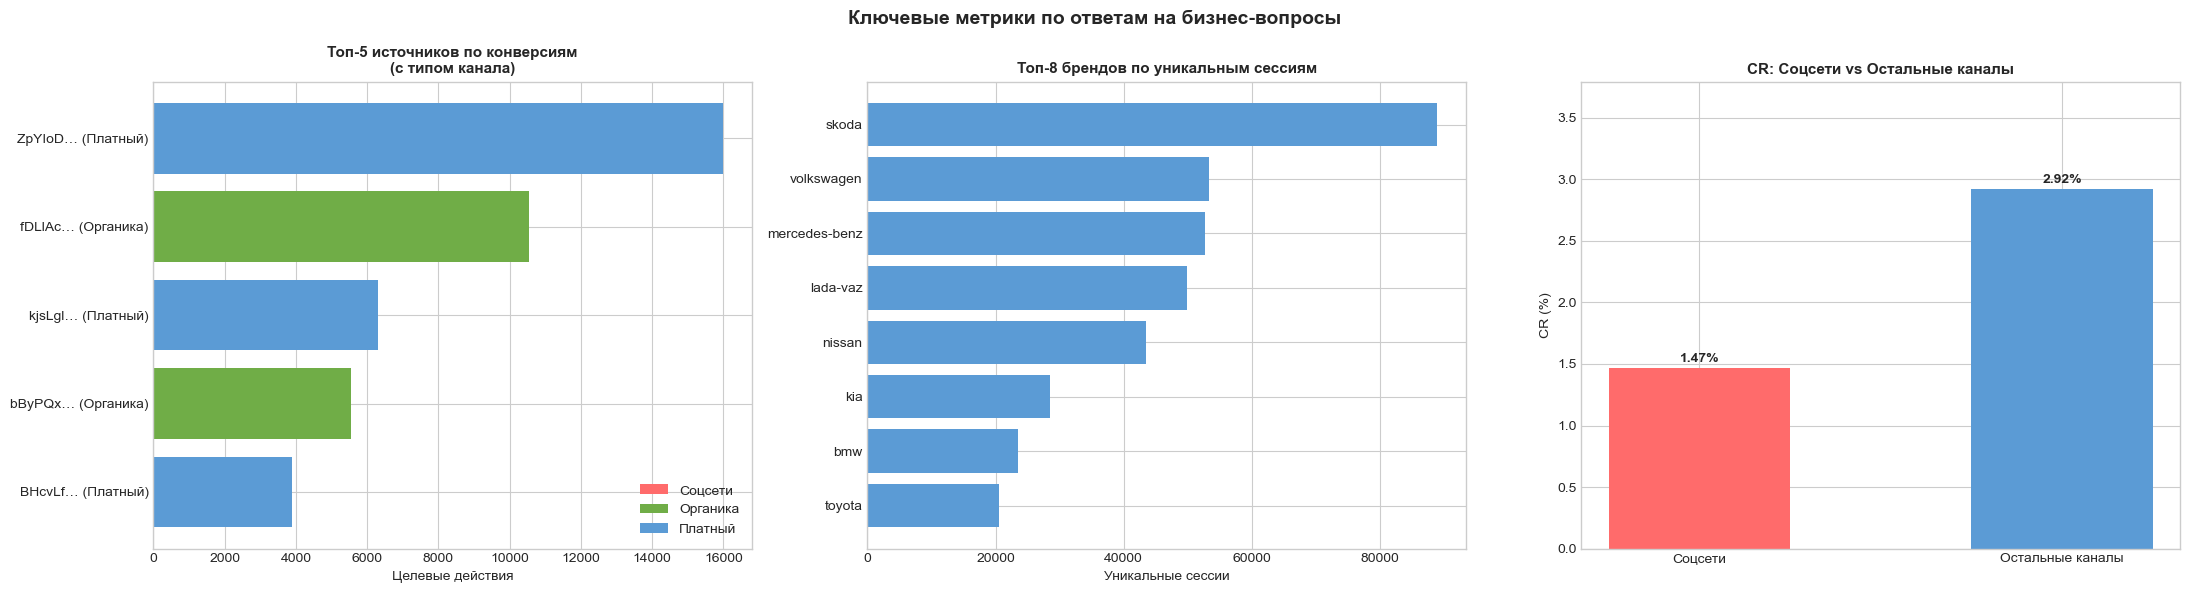

In [ ]:
# ВИЗУАЛИЗАЦИИ К ОТВЕТАМ НА БИЗНЕС-ВОПРОСЫ
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Ключевые метрики по ответам на бизнес-вопросы', fontsize=14, fontweight='bold')

# График 1: Топ-5 источников по объёму конверсий с цветовой кодировкой
color_map = {'Соцсети': '#ff6b6b', 'Органика': '#70ad47', 'Платный': '#5b9bd5'}

plot_data = top_by_volume.head(5).iloc[::-1].copy()
plot_data['label'] = [f"{s[:6]}… ({t})" for s, t in zip(plot_data['utm_source'], plot_data['channel_type'])]

axes[0].barh(plot_data['label'], plot_data['conversions'],
             color=[color_map[t] for t in plot_data['channel_type']])
axes[0].set_title('Топ-5 источников по конверсиям\n(с типом канала)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Целевые действия')
axes[0].legend(handles=[Patch(facecolor=c, label=t) for t, c in color_map.items()], loc='lower right')

# График 2: Структура спроса по брендам (Treemap-стиль через barh)
# Используем данные из Шага 6 (brand_summary_filtered)
try:
    top_brands = brand_summary_filtered.nlargest(8, 'unique_sessions').iloc[::-1]
    axes[1].barh(top_brands['car_brand'], top_brands['unique_sessions'], color='#5b9bd5')
    axes[1].set_title('Топ-8 брендов по уникальным сессиям', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Уникальные сессии')
except NameError:
    axes[1].text(0.5, 0.5, 'Данные по брендам\nнедоступны\n(запустите Шаг 6)',
                 ha='center', va='center', fontsize=12)
    axes[1].set_title('Структура спроса по брендам', fontsize=11, fontweight='bold')

# График 3: CR соцсетей vs Остальные каналы
bars = axes[2].bar(['Соцсети', 'Остальные каналы'],
                    [total_social_cr * 100, total_other_cr * 100],
                    color=['#ff6b6b', '#5b9bd5'], width=0.5)
for b in bars:
    axes[2].text(b.get_x() + b.get_width()/2., b.get_height() + 0.05,
                 f'{b.get_height():.2f}%', ha='center', fontweight='bold', fontsize=10)
axes[2].set_title('CR: Соцсети vs Остальные каналы', fontsize=11, fontweight='bold')
axes[2].set_ylabel('CR (%)')
axes[2].set_ylim(0, max(total_social_cr, total_other_cr) * 100 * 1.3)

plt.tight_layout()
plt.show()

## ИТОГОВОЕ ЗАКЛЮЧЕНИЕ

### 1. Общая характеристика данных
- **Объём данных:** 1 860 042 сессии, 15 726 470 событий (хитов)
- **Общий CR:** 2,70% (50 314 целевых сессий)
- **Доля органического трафика:** 27,7%
- **Доля мобильного трафика:** 79,3%
- **Доля городов присутствия (МСК/СПб):** 64,6%
- **Доля соцсетей:** 14,7%

---

### 2. Результаты проверки гипотез

| Гипотеза | Результат | p-value | Lift | Cohen's h | Практическая значимость |
|---|---|---|---|---|---|
| **H1:** Органика ≠ Платный по CR | Отвергнута | ≈ 0 | **+83,9%** | 0,107 | **Да** — органика конвертируется почти вдвое лучше |
| **H2:** Мобильные ≠ Десктоп по CR | Отвергнута | 3,7×10⁻⁶⁴ | −16,0% | 0,030 | Нет — различие пренебрежимо мало |
| **H3:** Города присутствия ≠ Другие по CR | Отвергнута | 6,1×10⁻¹³ | +7,2% | 0,012 | Нет — различие пренебрежимо мало |

**Вывод:** Единственное практически значимое различие обнаружено между органическим и платным трафиком (H1). Устройство пользователя и география практически не влияют на конверсию.

---

### 3. Ответы на бизнес-вопросы

#### 3.1. Самый целевой трафик
- **По объёму конверсий:** `ZpYIoD…` (Платный, 15 998 конверсий), `fDLlAc…` (Органика, 10 531), `kjsLgl…` (Платный, 6 293)
- **По CR:** органические источники `oZCzWS…` (8,27%), `aXQzDW…` (5,86%), `bByPQx…` (5,43%)
- **По устройствам:** Desktop (CR = 3,14%) > Mobile (2,60%) > Tablet (2,31%)
- **По городам:** Москва лидирует по объёму (23 629 конверсий); Домодедово — по CR (6,51%)

#### 3.2. Спрос на автомобили
- **Топ-3 по просмотрам:** Skoda Rapid (442 779), Lada Vesta (404 150), VW Polo (318 264)
- **Топ-3 по CR:** Kia Rio (9,04%), Toyota Camry (8,72%), VW Polo (8,29%)
- **Лучшее сочетание спроса и конверсии:** **Volkswagen Polo** — высокий объём (41 325 сессий) и отличный CR (8,29%)

#### 3.3. Соцсети
- CR соцсетей **1,47%** vs остальных каналов **2,92%** (lift = −49,8%, p ≈ 0)
- Однако соцсети обеспечивают **14,7% всего трафика** (274 227 сессий)
- **Рекомендация:** не сокращать присутствие, а оптимизировать креативы и аудитории; использовать соцсети как верхнеуровневый канал awareness с последующим ретаргетингом

---

### 4. Ключевые рекомендации для продуктовой команды

1. **Инвестировать в SEO и органический трафик**: органика конвертируется на 83,9% лучше платного при меньших затратах
2. **Усилить продвижение VW Polo, Kia Rio и Toyota Camry**: модели с высоким спросом и лучшим CR
3. **Не сокращать рекламу в соцсетях**, но пересмотреть таргетинг и креативы для повышения качества трафика
4. **Не дифференцировать стратегию по устройствам и географии**: различия статистически значимы, но практически ничтожны
5. **Оптимизировать воронку для Mercedes-Benz**: высокий объём просмотров (475 765), но низкий CR (3,82%) указывает на разрыв между интересом и конверсией

---

### 5. Ограничения анализа
- Данные о конверсии атрибутируются по модели last-click (системы веб-аналитики)
- CR по моделям авто завышен из-за мультипросмотров в рамках одной сессии
- Часть utm-параметров анонимизирована, что ограничивает глубину анализа рекламных кампаний
- География определена по IP и может содержать ~4,2% пропусков